# 🦕 A Hybrid Paleontological Study
## Unsupervised Eco-Zone Mapping and Supervised Species Classification of Mesozoic Dinosaurs

**Course:** Machine Learning  
**Datasets:**
- `dataset/dinosaur_genera.csv` — Dinosaur Genera Dataset (Can Özensoy)
- `dataset/dinosaur_locations.csv` — Fossil Occurrence Dataset (Smruthiiii)

---
**Project Overview:**  
This notebook combines *unsupervised* and *supervised* machine learning techniques on real paleontological data. We first use clustering to discover geographical eco-zones from fossil occurrence records, then leverage those cluster labels as an engineered feature to improve diet classification models.


## 0. Imports & Configuration
We begin by importing all the required libraries. Notice we are **not** using any deep learning frameworks — only classical scikit-learn, pandas, numpy, matplotlib, seaborn, and scipy.


In [1]:
# Standard data science libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import warnings
import os
warnings.filterwarnings('ignore')

# Create output directory for plots
os.makedirs('output', exist_ok=True)

# Scikit-learn — preprocessing, imputation & utilities
from sklearn.preprocessing import StandardScaler, LabelEncoder, OneHotEncoder
from sklearn.impute import KNNImputer
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score, StratifiedKFold

# Scikit-learn — clustering
from sklearn.cluster import KMeans, DBSCAN, AgglomerativeClustering
from sklearn.decomposition import PCA

# Scikit-learn — supervised models
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier, plot_tree, export_text
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.linear_model import LinearRegression

# Scikit-learn — metrics
from sklearn.metrics import (
    silhouette_score, davies_bouldin_score,
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report,
    r2_score, mean_absolute_error, mean_squared_error
)

# Scipy for dendrogram
from scipy.cluster.hierarchy import dendrogram, linkage

# Global plot style
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("husl")
plt.rcParams['figure.dpi'] = 100

EARTH_RADIUS_KM = 6371.0088

print("✅ All libraries imported successfully!")
print(f"   pandas  {pd.__version__}  |  numpy  {np.__version__}  |  sklearn ready")


✅ All libraries imported successfully!
   pandas  2.3.3  |  numpy  2.3.5  |  sklearn ready


---
## 1. Dataset Loading & Initial Exploration

We load both CSV files and do a first look at their shape, data types, and missing values before any cleaning.

| File | Description |
|------|-------------|
| `dinosaur_genera.csv` | 1 542 dinosaur genera with physical attributes (length, weight, height, diet, locomotion, period, region) |
| `dinosaur_locations.csv` | 4 951 fossil occurrence records with GPS coordinates, geological age, and dietary group |


In [2]:
# ── Load Genera Dataset ──────────────────────────────────────────────
genera_df = pd.read_csv('dataset/dinosaur_genera.csv')

print("=" * 55)
print("  DINOSAUR GENERA DATASET")
print("=" * 55)
print(f"Shape: {genera_df.shape[0]} rows × {genera_df.shape[1]} columns\n")
display(genera_df.head(5))


  DINOSAUR GENERA DATASET
Shape: 1542 rows × 17 columns



,scientific_name,common_name,meaning,diet,length_m,weight_kg,height_m,locomotion,geological_period,lived_in,behavior_notes,first_discovered,fossil_location,notable_features,intelligence_level,source_link,row_index
0,Abelisaurus,Abelisaurus,Abel's lizard,Carnivore,7.0,1500.0,2.4,Bipedal,Late Cretaceous,Argentina,Large theropod,1985,Argentina,Short arms,Medium,https://en.wikipedia.org/wiki/Abelisaurus,0
1,Abrictosaurus,Abrictosaurus,Wakeful lizard,Herbivore,1.5,15.0,0.5,Bipedal,Early Jurassic,South Africa,Small herbivore,1974,South Africa,Unique teeth,Medium,https://en.wikipedia.org/wiki/Abrictosaurus,1
2,Abrosaurus,Abrosaurus,Delicate lizard,Herbivore,9.0,2000.0,4.5,Quadrupedal,Middle Jurassic,China,Delicate skull,1959,China,Delicate skull,Medium,https://en.wikipedia.org/wiki/Abrosaurus,2
3,Abydosaurus,Abydosaurus,Abydos lizard,Herbivore,18.0,30000.0,6.0,Quadrupedal,Early Cretaceous,USA,Basal sauropod,2010,USA,Complete skull,Medium,https://en.wikipedia.org/wiki/Abydosaurus,3
4,Acantholipan,Acantholipan,Spiny shield,Herbivore,5.0,2500.0,1.5,Quadrupedal,Late Cretaceous,Mexico,Armored nodosaur,2011,Mexico,Clubless armored tail,Medium,https://en.wikipedia.org/wiki/Acantholipan,4


In [3]:
print("\n--- Data Types & Missing Values (Genera) ---")
info_genera = pd.DataFrame({
    'dtype':   genera_df.dtypes,
    'missing': genera_df.isnull().sum(),
    'missing%': (genera_df.isnull().mean() * 100).round(2)
})
display(info_genera)



--- Data Types & Missing Values (Genera) ---


,dtype,missing,missing%
scientific_name,object,0,0.00
common_name,object,0,0.00
meaning,object,0,0.00
diet,object,0,0.00
length_m,float64,39,2.53
weight_kg,float64,38,2.46
height_m,float64,32,2.08
locomotion,object,0,0.00
geological_period,object,0,0.00
lived_in,object,0,0.00


In [4]:
# ── Load Locations Dataset ───────────────────────────────────────────
locations_df = pd.read_csv('dataset/dinosaur_locations.csv')

print("=" * 55)
print("  FOSSIL LOCATIONS DATASET")
print("=" * 55)
print(f"Shape: {locations_df.shape[0]} rows × {locations_df.shape[1]} columns\n")
display(locations_df.head(5))

print("\n--- Data Types & Missing Values (Locations) ---")
info_loc = pd.DataFrame({
    'dtype':   locations_df.dtypes,
    'missing': locations_df.isnull().sum(),
    'missing%': (locations_df.isnull().mean() * 100).round(2)
})
display(info_loc)


  FOSSIL LOCATIONS DATASET
Shape: 4951 rows × 12 columns



,occurrence_no,name,diet,type,length_m,max_ma,min_ma,region,lng,lat,class,family
0,130294,Protarchaeopteryx,omnivorous,small theropod,2.0,130.0,122.46,Liaoning,120.733330,41.799999,Saurischia,Archaeopterygidae
1,130295,Caudipteryx,omnivorous,small theropod,1.0,130.0,122.46,Liaoning,120.733330,41.799999,Saurischia,Caudipterygidae
2,139242,Gorgosaurus,carnivorous,large theropod,8.6,83.5,70.60,Alberta,-111.528732,50.740726,Saurischia,Tyrannosauridae
3,139250,Gorgosaurus,carnivorous,large theropod,8.6,83.5,70.60,Alberta,-111.549347,50.737015,Saurischia,Tyrannosauridae
4,139252,Gorgosaurus,carnivorous,large theropod,8.6,83.5,70.60,Alberta,-111.564636,50.723866,Saurischia,Tyrannosauridae



--- Data Types & Missing Values (Locations) ---


,dtype,missing,missing%
occurrence_no,int64,0,0.00
name,object,0,0.00
diet,object,1355,27.37
type,object,1355,27.37
length_m,float64,1383,27.93
max_ma,float64,0,0.00
min_ma,float64,0,0.00
region,object,42,0.85
lng,float64,0,0.00
lat,float64,0,0.00


---
## Phase 1 — Data Preprocessing

Good models need clean data. In this phase we:
1. **Keep only useful columns** and explain why others were dropped.
2. **Clean & standardize** categorical labels (diet, locomotion).
3. **Handle missing values** and remove duplicates.
4. **Scale numeric features** with `StandardScaler`.
5. **Visualize** distributions and correlations.

### Why StandardScaler is Critical for Distance-Based Algorithms
Algorithms like **KNN**, **K-Means**, and **DBSCAN** compute distances between data points.  
If one feature is measured in kilograms (0–80 000 kg) and another in metres (0–40 m), the kilogram feature will *dominate* the distance calculation simply because it has larger numbers — not because it is more important.  
`StandardScaler` transforms each feature to have **mean = 0** and **standard deviation = 1**, ensuring all features contribute equally to distance computations.


In [5]:
# ── 1.1  Genera Dataset Cleaning + KNN Trait Imputation ────────────────

# Columns we keep and why:
#   scientific_name      → identifier used for interpretation
#   diet                 → classification target
#   length_m, weight_kg, height_m → physical traits for morphology
#   locomotion           → movement type; useful taxonomic/morphological context
#   geological_period    → temporal context
#   lived_in             → coarse geographic context

genera_keep = ['scientific_name', 'diet', 'length_m', 'weight_kg', 'height_m',
               'locomotion', 'geological_period', 'lived_in']
genera_clean = genera_df[genera_keep].copy()

# --- Standardize Diet Labels ---
# We collapse noisy variants to 3 core classes: Herbivore, Carnivore, Omnivore
diet_map_genera = {
    'Herbivore': 'Herbivore',
    'Carnivore': 'Carnivore',
    'Omnivore': 'Omnivore',
    'Carnivore (disputed)': 'Carnivore',
    'Possibly carnivore': 'Carnivore',
    'Insectivore': 'Omnivore',
    'Unknown': None,
    'Ceric unknown': None
}
genera_clean['diet'] = genera_clean['diet'].map(diet_map_genera)
genera_clean.dropna(subset=['diet'], inplace=True)

# --- Standardize Locomotion Labels ---
def clean_locomotion(val):
    v = str(val).lower().strip()
    if '?' in v or v in ['unknown', 'locomotion', 'varies', 'nan']:
        return 'Unknown'
    if 'aquatic' in v:
        return 'Aquatic'
    if 'bipedal' in v and 'quad' in v:
        return 'Bipedal/Quadrupedal'
    if 'bipedal' in v:
        return 'Bipedal'
    if 'quad' in v:
        return 'Quadrupedal'
    return 'Unknown'

genera_clean['locomotion'] = genera_clean['locomotion'].apply(clean_locomotion)
for col in ['geological_period', 'lived_in']:
    genera_clean[col] = genera_clean[col].fillna('Unknown').astype(str)

# --- Academic Missing Data Fix: KNNImputer instead of dropna() ---
# Missing physical traits are estimated from nearby dinosaurs in a joint space of
# scaled morphology + taxonomic/contextual one-hot features. This preserves rows
# and approximates imputation from related taxa rather than discarding fossils.
genera_numeric_cols = ['length_m', 'weight_kg', 'height_m']
genera_context_cols = ['diet', 'locomotion', 'geological_period', 'lived_in']

missing_before = genera_clean[genera_numeric_cols].isna().sum()

try:
    context_encoder = OneHotEncoder(handle_unknown='ignore', sparse_output=False)
except TypeError:
    context_encoder = OneHotEncoder(handle_unknown='ignore', sparse=False)

context_encoded = context_encoder.fit_transform(genera_clean[genera_context_cols])
trait_scaler_for_impute = StandardScaler()
scaled_traits = trait_scaler_for_impute.fit_transform(genera_clean[genera_numeric_cols])

imputation_matrix = np.hstack([scaled_traits, context_encoded])
trait_imputer = KNNImputer(n_neighbors=5, weights='distance')
imputed_matrix = trait_imputer.fit_transform(imputation_matrix)

genera_clean[genera_numeric_cols] = trait_scaler_for_impute.inverse_transform(
    imputed_matrix[:, :len(genera_numeric_cols)]
)

# Remove impossible or nonpositive physical estimates after imputation
for col in genera_numeric_cols:
    genera_clean = genera_clean[genera_clean[col] > 0]

# --- Remove Duplicates ---
before = len(genera_clean)
genera_clean.drop_duplicates(inplace=True)
genera_clean.reset_index(drop=True, inplace=True)
after = len(genera_clean)

print(f"Genera dataset after cleaning + KNN imputation: {genera_clean.shape}")
print(f"  Duplicates removed: {before - after}")
print("\nMissing physical traits before imputation:")
print(missing_before)
print("\nMissing physical traits after imputation:")
print(genera_clean[genera_numeric_cols].isna().sum())
print("\nDiet distribution:")
print(genera_clean['diet'].value_counts())
print("\nLocomotion distribution:")
print(genera_clean['locomotion'].value_counts())


Genera dataset after cleaning + KNN imputation: (1530, 8)
  Duplicates removed: 0

Missing physical traits before imputation:
length_m     31
weight_kg    30
height_m     24
dtype: int64

Missing physical traits after imputation:
length_m     0
weight_kg    0
height_m     0
dtype: int64

Diet distribution:
diet
Herbivore    971
Carnivore    505
Omnivore      54
Name: count, dtype: int64

Locomotion distribution:
locomotion
Bipedal                910
Quadrupedal            594
Bipedal/Quadrupedal     15
Unknown                  8
Aquatic                  3
Name: count, dtype: int64


In [6]:
# ── 1.2  Locations Dataset Cleaning ─────────────────────────────────────

# Columns we keep:
#   name       → dinosaur name (identifier)
#   diet       → classification target (for supervised phase)
#   type       → broad morphological category
#   length_m   → physical size estimate
#   max_ma     → geological age upper bound (million years ago)
#   min_ma     → geological age lower bound
#   region     → named fossil region
#   lng, lat   → GPS coordinates (KEY for clustering)
#   class      → taxonomic class (Saurischia / Ornithischia)
#
# Columns dropped:
#   occurrence_no → database ID (no ML value)
#   family        → >29% missing; 'type' covers morphology well enough

# Filter records with valid GPS coordinates (some lng values exceed 180°)
locations_clean = locations_df[
    locations_df['lng'].between(-180, 180) &
    locations_df['lat'].between(-90, 90)
].copy()

loc_keep = ['name', 'diet', 'type', 'length_m', 'max_ma', 'min_ma',
            'region', 'lng', 'lat', 'class']
locations_clean = locations_clean[loc_keep].copy()

# --- Standardize Diet Labels ---
diet_map_loc = {
    'herbivorous': 'Herbivore',
    'carnivorous':  'Carnivore',
    'omnivorous':   'Omnivore'
}
locations_clean['diet'] = locations_clean['diet'].map(diet_map_loc)

# Drop records missing both diet and length (needed for supervised phase)
locations_clean.dropna(subset=['diet', 'length_m'], inplace=True)
locations_clean.drop_duplicates(inplace=True)
locations_clean.reset_index(drop=True, inplace=True)

print(f"Locations dataset after cleaning: {locations_clean.shape}")
print("\nDiet distribution:")
print(locations_clean['diet'].value_counts())
print("\nType distribution:")
print(locations_clean['type'].value_counts().head(8))


Locations dataset after cleaning: (3117, 10)

Diet distribution:
diet
Herbivore    1778
Carnivore    1136
Omnivore      203
Name: count, dtype: int64

Type distribution:
type
ornithopod          705
large theropod      652
small theropod      619
sauropod            565
ceratopsian         317
armored dinosaur    259
Name: count, dtype: int64


In [7]:
# ── 1.3  Feature Scaling ─────────────────────────────────────────────────

# Scale the three physical measurements in the genera dataset
genera_numeric_cols = ['length_m', 'weight_kg', 'height_m']
scaler_genera = StandardScaler()
genera_scaled_vals = scaler_genera.fit_transform(genera_clean[genera_numeric_cols])
genera_scaled = pd.DataFrame(genera_scaled_vals, columns=genera_numeric_cols, index=genera_clean.index)

# Scale geo features for clustering (will be done again in Phase 2 for clarity)
geo_cols = ['lat', 'lng']
scaler_geo = StandardScaler()
geo_scaled_vals = scaler_geo.fit_transform(locations_clean[geo_cols])

print("Genera numeric features — before scaling (sample stats):")
display(genera_clean[genera_numeric_cols].describe().round(2))

print("\nGenera numeric features — after StandardScaler:")
display(pd.DataFrame(genera_scaled_vals, columns=genera_numeric_cols).describe().round(4))


Genera numeric features — before scaling (sample stats):


,length_m,weight_kg,height_m
count,1530.00,1530.00,1530.00
mean,6.74,3898.48,2.39
std,5.52,7543.22,1.69
min,0.30,0.10,0.10
25%,3.00,100.00,1.00
50%,6.00,1500.00,2.00
75%,9.00,4000.00,3.00
max,37.00,75000.00,12.00



Genera numeric features — after StandardScaler:


,length_m,weight_kg,height_m
count,1530.0000,1530.0000,1530.0000
mean,0.0000,0.0000,0.0000
std,1.0003,1.0003,1.0003
min,-1.1657,-0.5170,-1.3574
25%,-0.6768,-0.5037,-0.8238
50%,-0.1335,-0.3181,-0.2310
75%,0.4097,0.0135,0.3619
max,5.4800,9.4290,5.6979


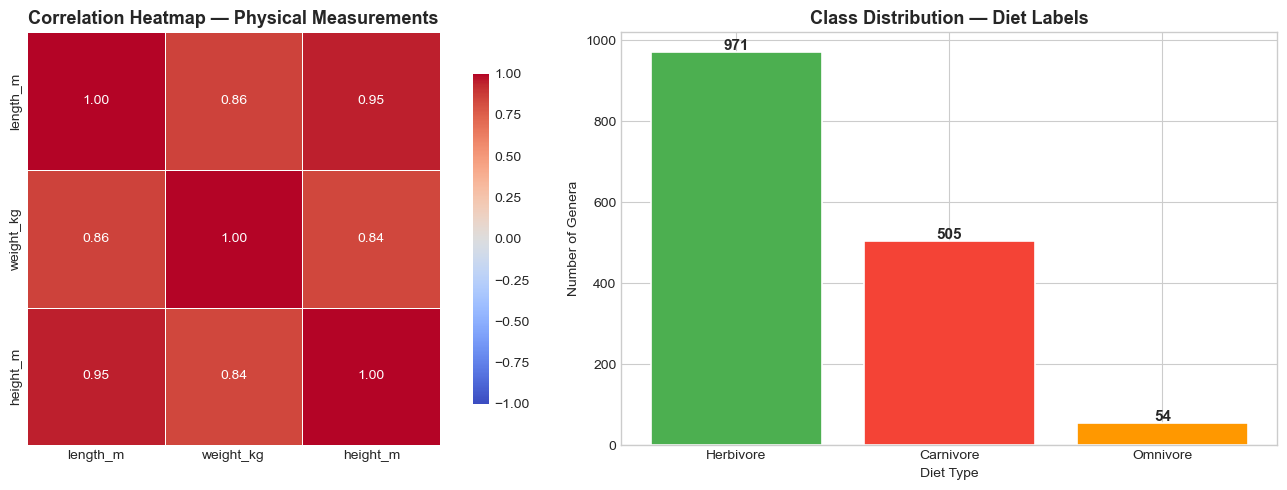

Correlation matrix saved as:
  output/correlation_matrix.png
  output/phase1_heatmap.png


In [8]:
# ── 1.4  Correlation Heatmap / Multicollinearity Validation ───────────

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Heatmap for physical traits
corr_matrix = genera_clean[genera_numeric_cols].corr(method='pearson')
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f',
            linewidths=0.5, ax=axes[0], vmin=-1, vmax=1,
            square=True, cbar_kws={'shrink': 0.8})
axes[0].set_title('Correlation Heatmap — Physical Measurements', fontsize=13, fontweight='bold')

# Diet count plot
diet_counts = genera_clean['diet'].value_counts()
colors_diet  = ['#4CAF50', '#F44336', '#FF9800']
axes[1].bar(diet_counts.index, diet_counts.values, color=colors_diet, edgecolor='white', linewidth=1.2)
axes[1].set_title('Class Distribution — Diet Labels', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Diet Type')
axes[1].set_ylabel('Number of Genera')
for i, v in enumerate(diet_counts.values):
    axes[1].text(i, v + 5, str(v), ha='center', fontweight='bold', fontsize=11)

plt.tight_layout()
plt.savefig('output/correlation_matrix.png', bbox_inches='tight', dpi=300)
plt.savefig('output/phase1_heatmap.png', bbox_inches='tight', dpi=300)
plt.show()

print("Correlation matrix saved as:")
print("  output/correlation_matrix.png")
print("  output/phase1_heatmap.png")


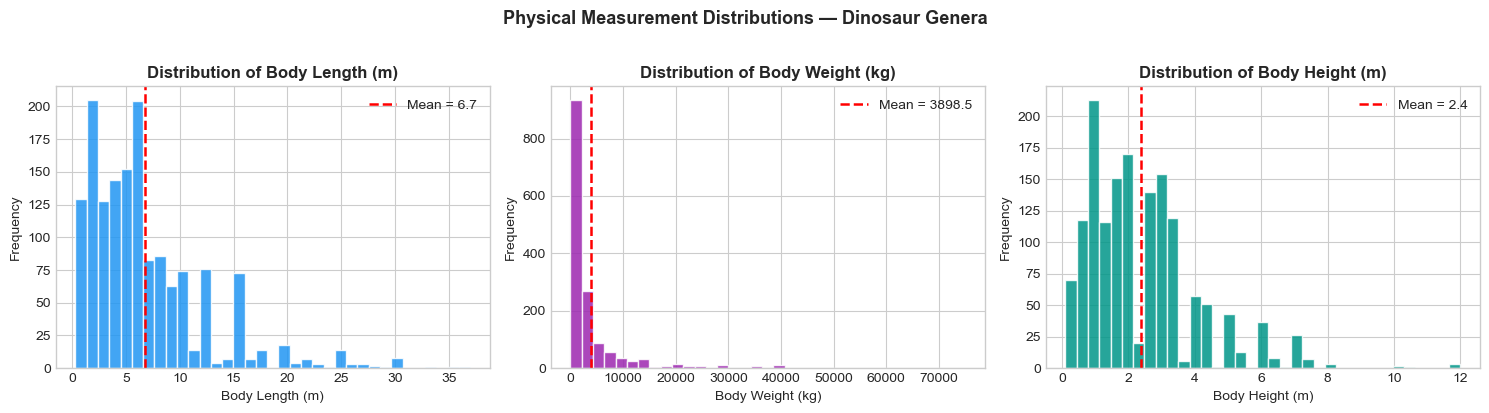


Key observation: Weight distribution is highly right-skewed (few giant sauropods
pull the mean far right). This is expected in paleontological datasets.


In [9]:
# ── 1.5  Distribution Plots ───────────────────────────────────────────────

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
col_labels = ['Body Length (m)', 'Body Weight (kg)', 'Body Height (m)']
palette    = ['#2196F3', '#9C27B0', '#009688']

for i, (col, label, color) in enumerate(zip(genera_numeric_cols, col_labels, palette)):
    axes[i].hist(genera_clean[col], bins=35, color=color, edgecolor='white', alpha=0.85)
    axes[i].axvline(genera_clean[col].mean(), color='red', linestyle='--',
                     linewidth=1.8, label=f'Mean = {genera_clean[col].mean():.1f}')
    axes[i].set_title(f'Distribution of {label}', fontweight='bold')
    axes[i].set_xlabel(label)
    axes[i].set_ylabel('Frequency')
    axes[i].legend()

plt.suptitle('Physical Measurement Distributions — Dinosaur Genera', fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('output/phase1_distributions.png', bbox_inches='tight')
plt.show()

print("\nKey observation: Weight distribution is highly right-skewed (few giant sauropods")
print("pull the mean far right). This is expected in paleontological datasets.")


---
## Phase 2 — Unsupervised Learning & Eco-Zone Profiling

We treat this phase as **fully unsupervised** — no diet or taxonomic labels are used.  
The input is purely geographical: **latitude** and **longitude** from the fossil occurrence records.

> **Goal:** Discover natural geographical clusters (eco-zones) where dinosaurs lived,  
> then engineer an `Eco_Zone_Cluster` feature that carries geographic context into our classifiers.

> ⚠️ **PCA Note:** PCA is used **only for 2-D visualisation** of the high-dimensional clusters.  
> All clustering algorithms are trained on the full scaled feature space — not on PCA components.


In [10]:
# ── 2.0  Prepare Geo Features for Clustering ─────────────────────────────

geo_df = locations_clean[['lat', 'lng']].copy()

# Comparative flat-plane representation retained only for K-Means, hierarchy,
# dendrograms, and PCA visualisation. It is NOT used for the final DBSCAN eco-zone.
scaler_geo = StandardScaler()
geo_scaled = scaler_geo.fit_transform(geo_df)

# Correct spherical representation for Haversine DBSCAN.
# scikit-learn expects radians ordered as [latitude, longitude].
geo_radians = np.radians(geo_df[['lat', 'lng']].to_numpy())
DBSCAN_RADIUS_KM = 750
DBSCAN_EPS_RAD = DBSCAN_RADIUS_KM / EARTH_RADIUS_KM
DBSCAN_MIN_SAMPLES = 12

# PCA for 2-D visualisation only — NOT used for training
pca_viz = PCA(n_components=2, random_state=42)
geo_pca = pca_viz.fit_transform(geo_scaled)

print(f"Clustering input shape       : {geo_scaled.shape}")
print(f"Haversine DBSCAN radius      : {DBSCAN_RADIUS_KM} km")
print(f"Haversine DBSCAN eps radians : {DBSCAN_EPS_RAD:.6f}")
print(f"PCA explained variance       : {pca_viz.explained_variance_ratio_.round(4)}")
print(f"Total variance captured      : {pca_viz.explained_variance_ratio_.sum():.2%}")
print("\n(PCA is only for plotting — final DBSCAN uses lat/lng radians + Haversine distance.)")


Clustering input shape       : (3117, 2)
Haversine DBSCAN radius      : 750 km
Haversine DBSCAN eps radians : 0.117721
PCA explained variance       : [0.6387 0.3613]
Total variance captured      : 100.00%

(PCA is only for plotting — final DBSCAN uses lat/lng radians + Haversine distance.)


### A. Elbow Method — Choosing the Optimal K
We run K-Means for K = 2 … 10 and record the **Inertia** (Within-Cluster Sum of Squares, WCSS).  
The "elbow" point — where adding more clusters gives diminishing returns — suggests the optimal K.


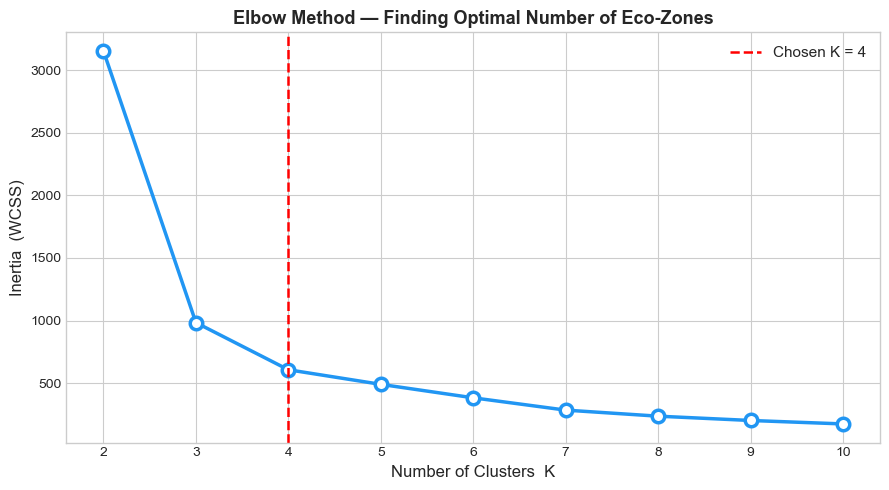


📍 Chosen K = 4  (clear elbow at this point)


In [11]:
# ── 2A  Elbow Method ─────────────────────────────────────────────────────

inertias = []
K_range  = range(2, 11)

for k in K_range:
    km_temp = KMeans(n_clusters=k, init='k-means++', n_init=10, random_state=42)
    km_temp.fit(geo_scaled)
    inertias.append(km_temp.inertia_)

plt.figure(figsize=(9, 5))
plt.plot(list(K_range), inertias, 'o-', color='#2196F3', linewidth=2.5, markersize=9,
         markerfacecolor='white', markeredgewidth=2.5)
plt.axvline(x=4, color='red', linestyle='--', linewidth=1.8, label='Chosen K = 4')
plt.xlabel('Number of Clusters  K', fontsize=12)
plt.ylabel('Inertia  (WCSS)', fontsize=12)
plt.title('Elbow Method — Finding Optimal Number of Eco-Zones', fontsize=13, fontweight='bold')
plt.xticks(list(K_range))
plt.legend(fontsize=11)
plt.tight_layout()
plt.savefig('output/phase2_elbow.png', bbox_inches='tight')
plt.show()

OPTIMAL_K = 4
print(f"\n📍 Chosen K = {OPTIMAL_K}  (clear elbow at this point)")


### B. Dendrogram — Hierarchical Structure of Fossil Sites
A **dendrogram** shows how individual points merge step by step into larger clusters.  
- Each **leaf** at the bottom represents one fossil site.  
- Branches merge points that are close together (Ward linkage minimises within-cluster variance).  
- The **height** of a horizontal bar shows the distance at which two groups merged.  
- Cutting the tree at a horizontal line gives you the desired number of clusters.

We sample 150 sites for readability.


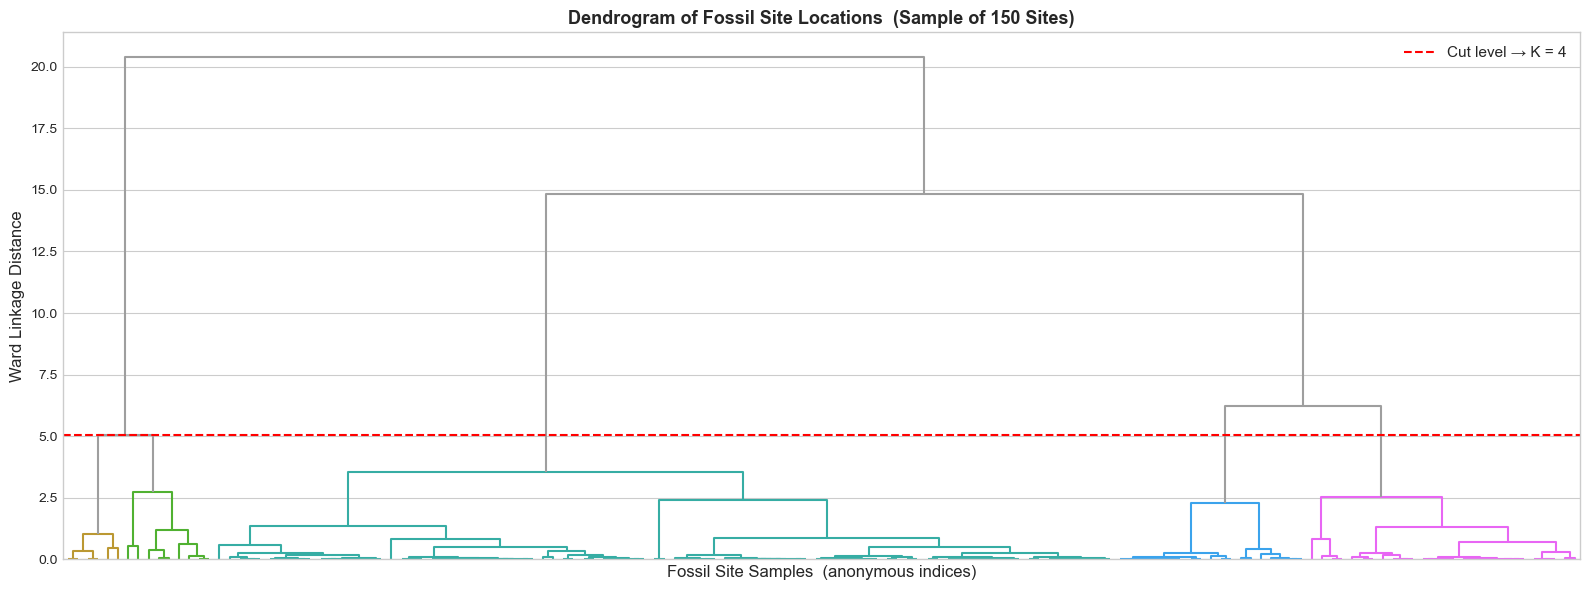

In [12]:
# ── 2B  Dendrogram ───────────────────────────────────────────────────────

np.random.seed(42)
sample_idx  = np.random.choice(len(geo_scaled), 150, replace=False)
geo_sample  = geo_scaled[sample_idx]

linked = linkage(geo_sample, method='ward')

plt.figure(figsize=(16, 6))
dendrogram(
    linked,
    no_labels=True,
    color_threshold=linked[-4, 2],   # colour groups above this distance
    above_threshold_color='#9E9E9E'
)
plt.axhline(y=linked[-4, 2], color='red', linestyle='--',
            linewidth=1.5, label=f'Cut level → K = {OPTIMAL_K}')
plt.xlabel('Fossil Site Samples  (anonymous indices)', fontsize=12)
plt.ylabel('Ward Linkage Distance', fontsize=12)
plt.title('Dendrogram of Fossil Site Locations  (Sample of 150 Sites)', fontsize=13, fontweight='bold')
plt.legend(fontsize=11)
plt.tight_layout()
plt.savefig('output/phase2_dendrogram.png', bbox_inches='tight')
plt.show()


### C. Hierarchical Clustering (Agglomerative)
`AgglomerativeClustering` builds clusters bottom-up, merging the nearest pair at each step.  
We use **Ward** linkage (same as the dendrogram) with K = 5.


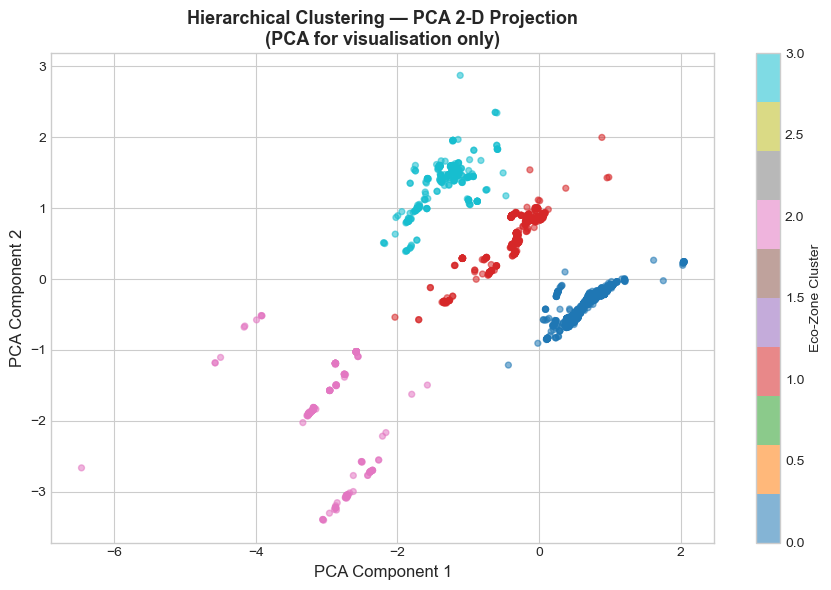

Hierarchical cluster sizes:
Cluster 0    1889
Cluster 1     561
Cluster 2     225
Cluster 3     442
Name: count, dtype: int64


In [13]:
# ── 2C  Hierarchical Clustering ─────────────────────────────────────────

hier = AgglomerativeClustering(n_clusters=OPTIMAL_K, linkage='ward')
hier_labels = hier.fit_predict(geo_scaled)

# Visualise with PCA projection
plt.figure(figsize=(9, 6))
scatter = plt.scatter(geo_pca[:, 0], geo_pca[:, 1],
                      c=hier_labels, cmap='tab10', alpha=0.55, s=18)
plt.colorbar(scatter, label='Eco-Zone Cluster')
plt.xlabel('PCA Component 1', fontsize=12)
plt.ylabel('PCA Component 2', fontsize=12)
plt.title('Hierarchical Clustering — PCA 2-D Projection\n(PCA for visualisation only)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('output/phase2_hier.png', bbox_inches='tight')
plt.show()

print("Hierarchical cluster sizes:")
hier_series = pd.Series(hier_labels)
print(hier_series.value_counts().sort_index().rename(lambda x: f"Cluster {x}"))


### D. K-Means++ — Optimal Eco-Zone Map
`K-Means++` improves upon standard K-Means by choosing initial centroids that are far apart,  
reducing the chance of bad initialisation. We use `init='k-means++'` with K = 5.


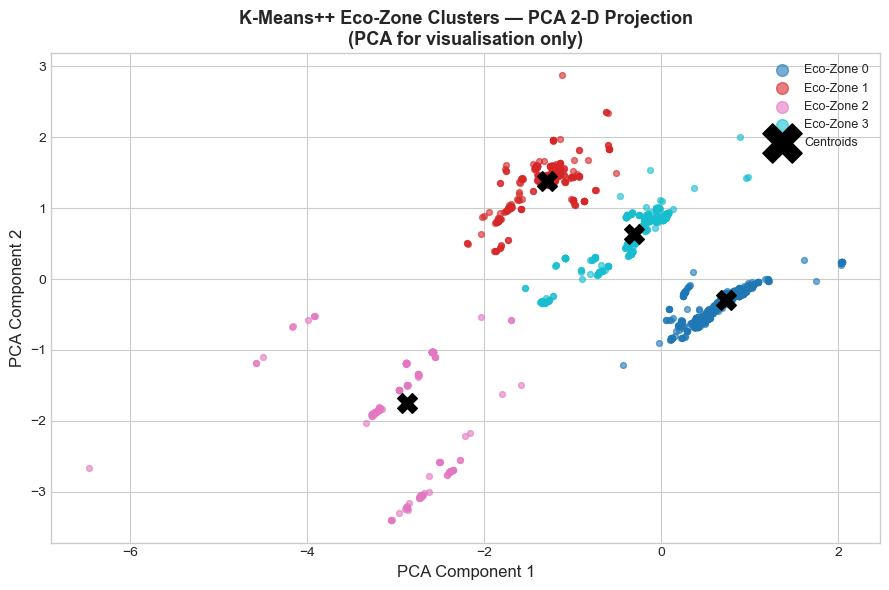

K-Means++ cluster sizes:
Eco-Zone 0    1889
Eco-Zone 1     441
Eco-Zone 2     228
Eco-Zone 3     559
Name: count, dtype: int64


In [14]:
# ── 2D  K-Means++ ────────────────────────────────────────────────────────

km_opt = KMeans(n_clusters=OPTIMAL_K, init='k-means++', n_init=10, random_state=42)
km_labels = km_opt.fit_predict(geo_scaled)

# Colour map with distinct colours
cmap_5 = plt.colormaps['tab10'].resampled(OPTIMAL_K)
colors_km = [cmap_5(i) for i in range(OPTIMAL_K)]

plt.figure(figsize=(9, 6))
for cluster_id in range(OPTIMAL_K):
    mask = km_labels == cluster_id
    plt.scatter(geo_pca[mask, 0], geo_pca[mask, 1],
                color=colors_km[cluster_id], alpha=0.6, s=18,
                label=f'Eco-Zone {cluster_id}')

# Plot centroids in PCA space (approximate)
centroids_pca = pca_viz.transform(km_opt.cluster_centers_)
plt.scatter(centroids_pca[:, 0], centroids_pca[:, 1],
            c='black', marker='X', s=200, zorder=5, label='Centroids')

plt.xlabel('PCA Component 1', fontsize=12)
plt.ylabel('PCA Component 2', fontsize=12)
plt.title('K-Means++ Eco-Zone Clusters — PCA 2-D Projection\n(PCA for visualisation only)', fontsize=13, fontweight='bold')
plt.legend(fontsize=9, markerscale=2)
plt.tight_layout()
plt.savefig('output/phase2_kmeans.png', bbox_inches='tight')
plt.show()

print("K-Means++ cluster sizes:")
km_series = pd.Series(km_labels)
print(km_series.value_counts().sort_index().rename(lambda x: f"Eco-Zone {x}"))


### E. DBSCAN — Density-Based Spatial Clustering
**DBSCAN** finds clusters of arbitrary shape by identifying high-density regions.  
It also marks low-density points as **noise** (label = −1), which in our context represents  
isolated fossil finds far from major fossil-bearing regions.

- `eps` — the neighbourhood radius  
- `min_samples` — minimum points to form a dense core


Haversine DBSCAN results:
  Radius              : 750 km
  eps in radians      : 0.117721
  Number of clusters  : 12
  Noise points        : 64  (2.1% of sites)


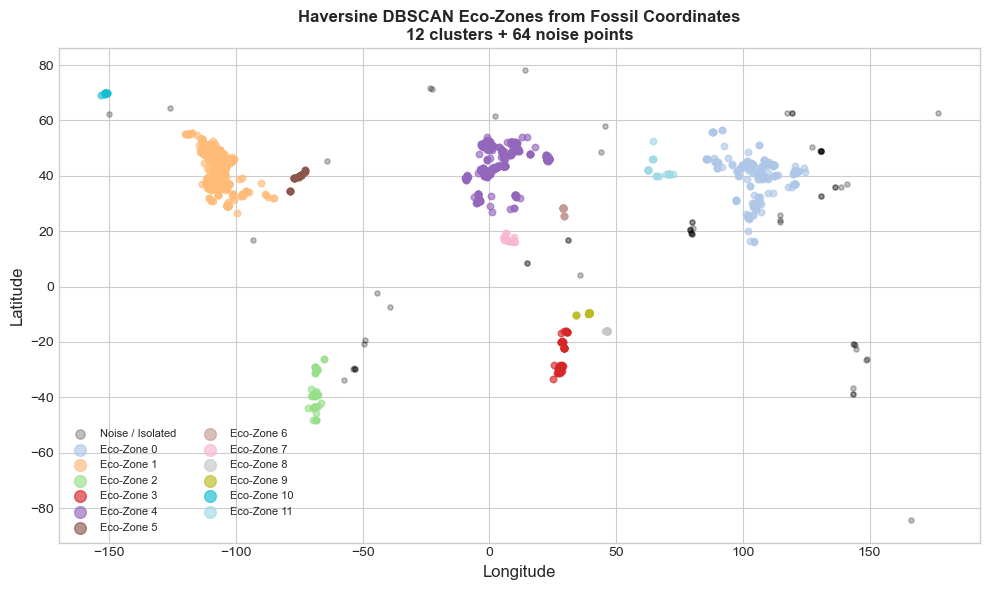

Haversine eco-zone plot saved as:
  output/clustering_plot.png
  output/phase2_dbscan.png


In [15]:
# ── 2E  Haversine DBSCAN ────────────────────────────────────────────────

# Academic spatial fix:
#   Raw GPS degrees are not Cartesian coordinates. We convert lat/lng to radians
#   and use metric='haversine', where eps is a true radius divided by Earth radius.
dbscan = DBSCAN(
    eps=DBSCAN_EPS_RAD,
    min_samples=DBSCAN_MIN_SAMPLES,
    metric='haversine',
    algorithm='ball_tree'
)
db_labels = dbscan.fit_predict(geo_radians)

n_db_clusters = len(set(db_labels)) - (1 if -1 in db_labels else 0)
n_noise_pts   = int((db_labels == -1).sum())

print("Haversine DBSCAN results:")
print(f"  Radius              : {DBSCAN_RADIUS_KM} km")
print(f"  eps in radians      : {DBSCAN_EPS_RAD:.6f}")
print(f"  Number of clusters  : {n_db_clusters}")
print(f"  Noise points        : {n_noise_pts}  ({n_noise_pts/len(db_labels)*100:.1f}% of sites)")

plt.figure(figsize=(10, 6))
unique_db_labels = sorted(set(db_labels))
cmap_db = plt.colormaps['tab20'].resampled(max(len(unique_db_labels), 1))

for i, label in enumerate(unique_db_labels):
    mask = db_labels == label
    if label == -1:
        plt.scatter(locations_clean.loc[mask, 'lng'], locations_clean.loc[mask, 'lat'],
                    color='black', alpha=0.25, s=14, label='Noise / Isolated')
    else:
        plt.scatter(locations_clean.loc[mask, 'lng'], locations_clean.loc[mask, 'lat'],
                    color=cmap_db(i), alpha=0.65, s=22, label=f'Eco-Zone {label}')

plt.xlabel('Longitude', fontsize=12)
plt.ylabel('Latitude', fontsize=12)
plt.title(f'Haversine DBSCAN Eco-Zones from Fossil Coordinates\n{n_db_clusters} clusters + {n_noise_pts} noise points',
          fontsize=12, fontweight='bold')
handles, labels = plt.gca().get_legend_handles_labels()
plt.legend(handles[:14], labels[:14], fontsize=8, markerscale=1.8, ncol=2)
plt.tight_layout()
plt.savefig('output/clustering_plot.png', bbox_inches='tight', dpi=300)
plt.savefig('output/phase2_dbscan.png', bbox_inches='tight', dpi=300)
plt.show()

print("Haversine eco-zone plot saved as:")
print("  output/clustering_plot.png")
print("  output/phase2_dbscan.png")


### F. Cluster Validity — Silhouette Score & Davies-Bouldin Index

| Metric | Ideal Value | Interpretation |
|--------|-------------|----------------|
| **Silhouette Score** | → +1 | Higher is better; measures how well each point fits its own cluster vs. neighbours |
| **Davies-Bouldin Index** | → 0 | Lower is better; ratio of intra-cluster scatter to inter-cluster separation |


Method               Silhouette   Davies-Bouldin
---------------------------------------------
K-Means++                0.7176           0.4953
Hierarchical             0.7168           0.5016
Haversine DBSCAN         0.6995           0.4716


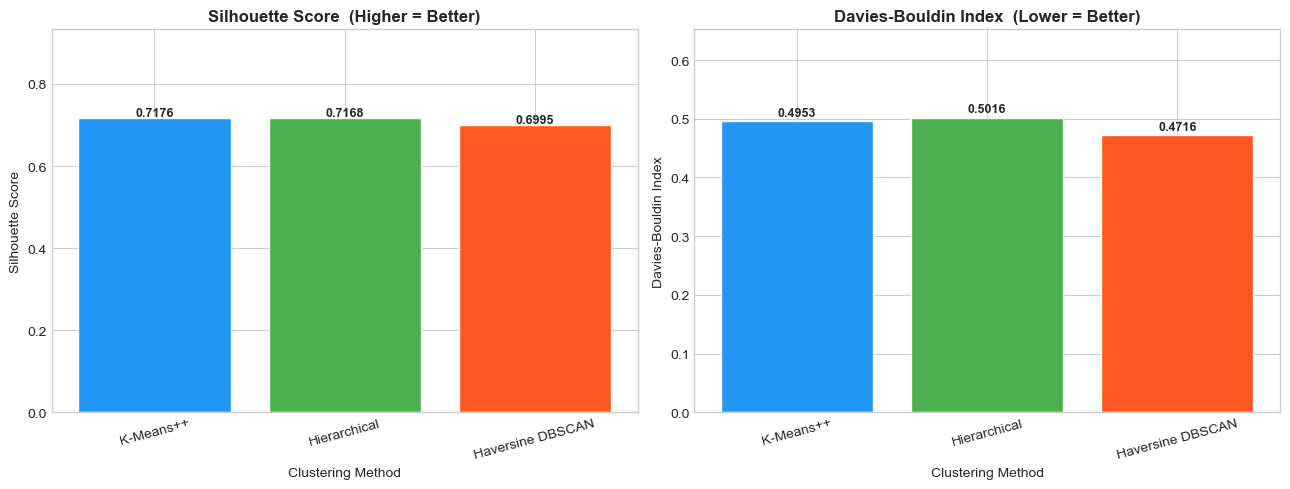


📊 DBSCAN is now evaluated using Haversine distance for the silhouette diagnostic.


In [16]:
# ── 2F  Cluster Validity ─────────────────────────────────────────────────

# Silhouette Scores for flat-plane comparison methods
sil_km   = silhouette_score(geo_scaled, km_labels)
sil_hier = silhouette_score(geo_scaled, hier_labels)

# Haversine DBSCAN: ignore noise points for validity calculation
# Silhouette uses the same Haversine metric as DBSCAN for methodological consistency.
db_valid_mask = db_labels != -1
n_db_valid_clusters = len(set(db_labels[db_valid_mask]))
if db_valid_mask.sum() > 1 and n_db_valid_clusters > 1:
    sil_db = silhouette_score(
        geo_radians[db_valid_mask],
        db_labels[db_valid_mask],
        metric='haversine'
    )
    # Davies-Bouldin is Euclidean by definition in sklearn; reported on standardized
    # coordinates only as an approximate diagnostic for visual comparison.
    dbi_db = davies_bouldin_score(geo_scaled[db_valid_mask], db_labels[db_valid_mask])
else:
    sil_db, dbi_db = np.nan, np.nan

# Davies-Bouldin Index for flat-plane methods
dbi_km   = davies_bouldin_score(geo_scaled, km_labels)
dbi_hier = davies_bouldin_score(geo_scaled, hier_labels)

print("=" * 45)
print(f"{'Method':<18} {'Silhouette':>12} {'Davies-Bouldin':>16}")
print("-" * 45)
for name, sil, dbi in [('K-Means++', sil_km, dbi_km),
                        ('Hierarchical', sil_hier, dbi_hier),
                        ('Haversine DBSCAN', sil_db, dbi_db)]:
    s = f"{sil:.4f}" if not np.isnan(sil) else "  N/A (noise)"
    d = f"{dbi:.4f}" if not np.isnan(dbi) else "  N/A"
    print(f"{name:<18} {s:>12} {d:>16}")
print("=" * 45)

# --- Bar Chart Comparison ---
methods  = ['K-Means++', 'Hierarchical', 'Haversine DBSCAN']
sil_vals = [sil_km, sil_hier, sil_db if not np.isnan(sil_db) else 0]
dbi_vals = [dbi_km, dbi_hier, dbi_db if not np.isnan(dbi_db) else 0]
bar_colors = ['#2196F3', '#4CAF50', '#FF5722']

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

bars1 = axes[0].bar(methods, sil_vals, color=bar_colors, edgecolor='white', linewidth=1)
axes[0].set_title('Silhouette Score  (Higher = Better)', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Clustering Method')
axes[0].set_ylabel('Silhouette Score')
axes[0].set_ylim(0, max(sil_vals) * 1.3 if max(sil_vals) > 0 else 1)
axes[0].tick_params(axis='x', rotation=15)
for bar, val in zip(bars1, sil_vals):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
                 f"{val:.4f}", ha='center', fontweight='bold', fontsize=9)

bars2 = axes[1].bar(methods, dbi_vals, color=bar_colors, edgecolor='white', linewidth=1)
axes[1].set_title('Davies-Bouldin Index  (Lower = Better)', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Clustering Method')
axes[1].set_ylabel('Davies-Bouldin Index')
axes[1].set_ylim(0, max(dbi_vals) * 1.3 if max(dbi_vals) > 0 else 1)
axes[1].tick_params(axis='x', rotation=15)
for bar, val in zip(bars2, dbi_vals):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                 f"{val:.4f}", ha='center', fontweight='bold', fontsize=9)

plt.tight_layout()
plt.savefig('output/phase2_validity.png', bbox_inches='tight', dpi=300)
plt.show()

print("\n📊 DBSCAN is now evaluated using Haversine distance for the silhouette diagnostic.")


### G. Feature Engineering — `Eco_Zone_Cluster`

We add the **K-Means++ cluster label** as a new categorical feature called `Eco_Zone_Cluster`  
to the locations dataset. This tells each supervised model *"which geographical eco-zone  
did this fossil come from?"* — a signal that pure physical measurements alone cannot capture.

**How this helps classification:**  
Different eco-zones had different vegetation, prey availability, and climate — which in turn  
shaped the diet composition of the dinosaurs living there. A carnivore-dominated eco-zone  
(e.g. a coastal predator belt) will have very different cluster membership from a herbivore zone  
(e.g. an inland floodplain). By including `Eco_Zone_Cluster`, we give the classifier a  
geographic prior that improves prediction without adding raw GPS coordinates as raw features.


In [17]:
# ── 2G  Add Eco_Zone_Cluster to Locations Dataset ─────────────────────────

# The final engineered eco-zone feature comes from Haversine DBSCAN, not flat-plane K-Means.
# Noise points receive -1, which remains informative as an "isolated fossil occurrence" flag.
locations_clean['Eco_Zone_Cluster'] = db_labels.astype(int)

print("Eco_Zone_Cluster added to locations dataframe using Haversine DBSCAN labels.")
print("\nCluster sizes:")
print(locations_clean['Eco_Zone_Cluster'].value_counts().sort_index()
      .rename(lambda x: "Noise / Isolated" if x == -1 else f"Eco-Zone {x}"))

print("\nDiet distribution per Eco-Zone:")
crosstab = pd.crosstab(locations_clean['Eco_Zone_Cluster'],
                       locations_clean['diet'],
                       normalize='index').round(3) * 100
crosstab.index = ["Noise / Isolated" if i == -1 else f"Eco-Zone {i}" for i in crosstab.index]
display(crosstab.style.format("{:.1f}%").background_gradient(cmap='YlOrRd', axis=1))


Eco_Zone_Cluster added to locations dataframe using Haversine DBSCAN labels.

Cluster sizes:
Eco_Zone_Cluster
Noise / Isolated      64
Eco-Zone 0           387
Eco-Zone 1          1841
Eco-Zone 2            48
Eco-Zone 3            79
Eco-Zone 4           505
Eco-Zone 5            30
Eco-Zone 6            20
Eco-Zone 7            26
Eco-Zone 8            20
Eco-Zone 9            59
Eco-Zone 10           14
Eco-Zone 11           24
Name: count, dtype: int64

Diet distribution per Eco-Zone:


diet,Carnivore,Herbivore,Omnivore
Noise / Isolated,35.9%,59.4%,4.7%
Eco-Zone 0,27.4%,57.9%,14.7%
Eco-Zone 1,40.2%,55.8%,4.0%
Eco-Zone 2,45.8%,50.0%,4.2%
Eco-Zone 3,7.6%,25.3%,67.1%
Eco-Zone 4,27.7%,70.5%,1.8%
Eco-Zone 5,43.3%,46.7%,10.0%
Eco-Zone 6,75.0%,25.0%,0.0%
Eco-Zone 7,69.2%,30.8%,0.0%
Eco-Zone 8,100.0%,0.0%,0.0%


---
## Phase 3 — Supervised Learning: Classification & Regression

### Dataset Setup
| Task | Dataset | Features | Target |
|------|---------|----------|--------|
| **Regression** | Genera | `length_m` | `weight_kg` |
| **Classification** | Locations + `Eco_Zone_Cluster` | `length_m`, `max_ma`, `min_ma`, `lat`, `lng`, `Eco_Zone_Cluster` | `diet` |

All models use an **80/20 stratified train-test split** (random_state = 42).


In [18]:
# ── 3.0  Prepare Classification Data ─────────────────────────────────────

CLASS_FEATURES = ['length_m', 'max_ma', 'min_ma', 'lat', 'lng', 'Eco_Zone_Cluster']
CLASS_TARGET   = 'diet'

class_df = locations_clean[CLASS_FEATURES + [CLASS_TARGET]].dropna().copy()

# Encode string labels → integers for sklearn
le = LabelEncoder()
y_cls_raw = class_df[CLASS_TARGET].values
y_cls     = le.fit_transform(y_cls_raw)
X_cls_df  = class_df[CLASS_FEATURES].copy()

# 80/20 stratified split first, then fit preprocessing only on the training set.
# This avoids leakage from test statistics into the training pipeline.
X_train_raw, X_test_raw, y_train, y_test = train_test_split(
    X_cls_df, y_cls, test_size=0.2, random_state=42, stratify=y_cls
)

scaler_cls = StandardScaler()
X_train = scaler_cls.fit_transform(X_train_raw)
X_test  = scaler_cls.transform(X_test_raw)

# Backward-compatible aliases used by the older KNN/Decision Tree cells.
X_cls = X_cls_df.values
X_cls_scaled = scaler_cls.transform(X_cls_df)

print(f"Classification dataset size  : {class_df.shape}")
print(f"Training samples             : {len(X_train)}")
print(f"Test samples                 : {len(X_test)}")
print(f"Classes                      : {le.classes_}")
print(f"Class balance in test set    : {dict(zip(le.classes_, np.bincount(y_test)))}")
print("\nLeakage control: StandardScaler is fitted only on X_train_raw and then applied to X_test_raw.")


Classification dataset size  : (3117, 7)
Training samples             : 2493
Test samples                 : 624
Classes                      : ['Carnivore' 'Herbivore' 'Omnivore']
Class balance in test set    : {'Carnivore': np.int64(227), 'Herbivore': np.int64(356), 'Omnivore': np.int64(41)}

Leakage control: StandardScaler is fitted only on X_train_raw and then applied to X_test_raw.


### A. Linear Regression — Predicting Dinosaur Weight from Length
We train a simple `LinearRegression` model on the Genera dataset to see  
how well body **length** predicts body **weight**. This is a classic allometric relationship  
well-known in palaeontology.


  LINEAR REGRESSION RESULTS
  R² Score : 0.7369
  MAE      : 2,553.9 kg
  RMSE     : 4,485.2 kg
  Slope    : 1,139.2 kg / m
  Intercept: -3,824.8 kg


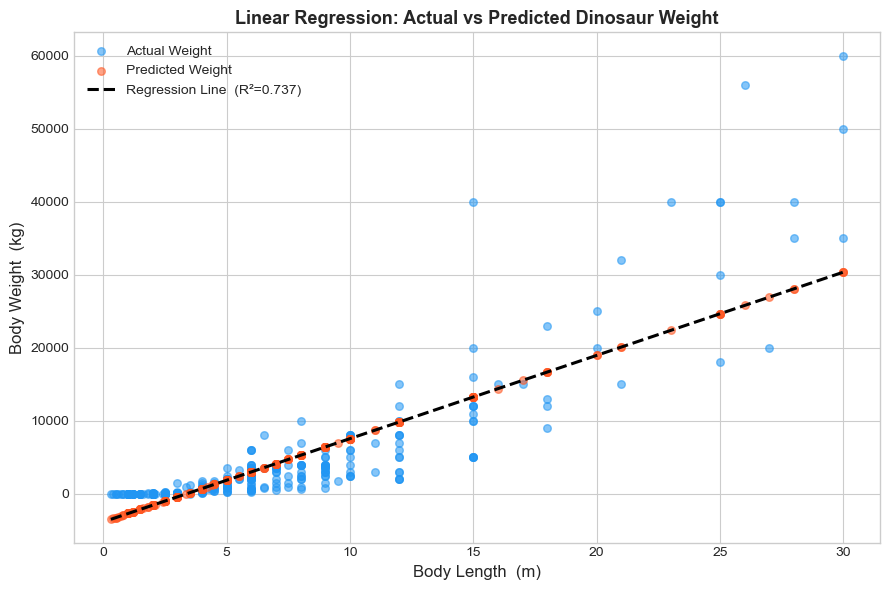

In [19]:
# ── 3A  Linear Regression ────────────────────────────────────────────────

reg_df = genera_clean[['length_m', 'weight_kg']].dropna().copy()
X_reg  = reg_df[['length_m']].values
y_reg  = reg_df['weight_kg'].values

X_train_r, X_test_r, y_train_r, y_test_r = train_test_split(
    X_reg, y_reg, test_size=0.2, random_state=42
)

lr = LinearRegression()
lr.fit(X_train_r, y_train_r)
y_pred_r = lr.predict(X_test_r)

r2   = r2_score(y_test_r, y_pred_r)
mae  = mean_absolute_error(y_test_r, y_pred_r)
rmse = np.sqrt(mean_squared_error(y_test_r, y_pred_r))

print("=" * 40)
print("  LINEAR REGRESSION RESULTS")
print("=" * 40)
print(f"  R² Score : {r2:.4f}")
print(f"  MAE      : {mae:,.1f} kg")
print(f"  RMSE     : {rmse:,.1f} kg")
print(f"  Slope    : {lr.coef_[0]:,.1f} kg / m")
print(f"  Intercept: {lr.intercept_:,.1f} kg")
print("=" * 40)

# ── Plot ───────────────────────────────────────────────────────────────
x_line  = np.linspace(X_test_r.min(), X_test_r.max(), 200).reshape(-1, 1)
y_line  = lr.predict(x_line)

plt.figure(figsize=(9, 6))
plt.scatter(X_test_r, y_test_r,   alpha=0.55, color='#2196F3', s=30, label='Actual Weight')
plt.scatter(X_test_r, y_pred_r,   alpha=0.55, color='#FF5722', s=30, label='Predicted Weight')
plt.plot(x_line, y_line, 'k--', linewidth=2.2, label=f'Regression Line  (R²={r2:.3f})')
plt.xlabel('Body Length  (m)', fontsize=12)
plt.ylabel('Body Weight  (kg)', fontsize=12)
plt.title('Linear Regression: Actual vs Predicted Dinosaur Weight', fontsize=13, fontweight='bold')
plt.legend(fontsize=10)
plt.tight_layout()
plt.savefig('output/phase3_regression.png', bbox_inches='tight')
plt.show()


### B. K-Nearest Neighbours (KNN) Classifier — Diet Prediction
KNN classifies each test point by looking at the K nearest training examples  
(using Euclidean distance in scaled feature space) and taking a majority vote.


KNN Accuracy: 0.8878

              precision    recall  f1-score   support

   Carnivore       0.88      0.83      0.86       227
   Herbivore       0.91      0.93      0.92       356
    Omnivore       0.71      0.85      0.78        41

    accuracy                           0.89       624
   macro avg       0.84      0.87      0.85       624
weighted avg       0.89      0.89      0.89       624



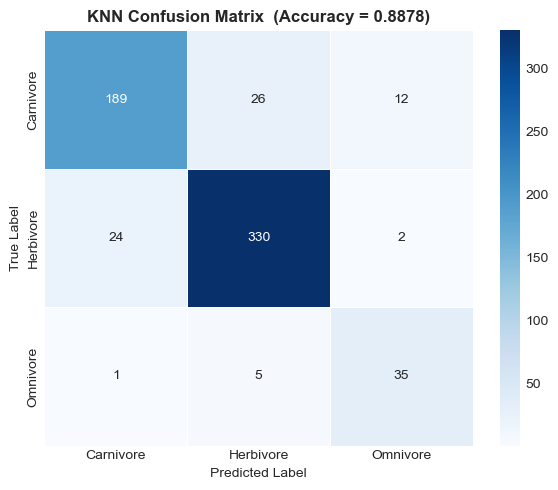

In [20]:
# ── 3B  KNN Classifier ───────────────────────────────────────────────────

knn = KNeighborsClassifier(n_neighbors=7, weights='distance', metric='euclidean')
knn.fit(X_train, y_train)
y_pred_knn = knn.predict(X_test)

acc_knn = accuracy_score(y_test, y_pred_knn)
print(f"KNN Accuracy: {acc_knn:.4f}\n")
print(classification_report(y_test, y_pred_knn, target_names=le.classes_))

# Confusion Matrix
cm_knn = confusion_matrix(y_test, y_pred_knn)
plt.figure(figsize=(6, 5))
sns.heatmap(cm_knn, annot=True, fmt='d', cmap='Blues',
            xticklabels=le.classes_, yticklabels=le.classes_, linewidths=0.5)
plt.title(f'KNN Confusion Matrix  (Accuracy = {acc_knn:.4f})', fontweight='bold')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.tight_layout()
plt.savefig('output/phase3_knn_cm.png', bbox_inches='tight')
plt.show()


### C. Decision Tree Classifier
A Decision Tree splits the data at each node on the feature + threshold that best  
separates the classes (using Gini impurity or entropy). The result is a set of  
human-readable IF-THEN rules.


Decision Tree Accuracy: 0.7692

              precision    recall  f1-score   support

   Carnivore       0.76      0.66      0.70       227
   Herbivore       0.77      0.88      0.82       356
    Omnivore       0.84      0.39      0.53        41

    accuracy                           0.77       624
   macro avg       0.79      0.64      0.69       624
weighted avg       0.77      0.77      0.76       624



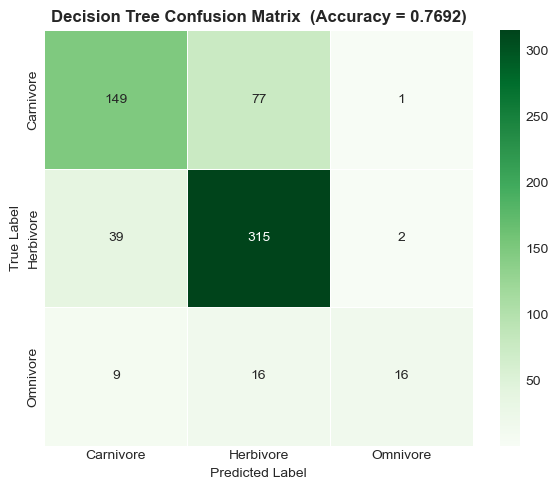

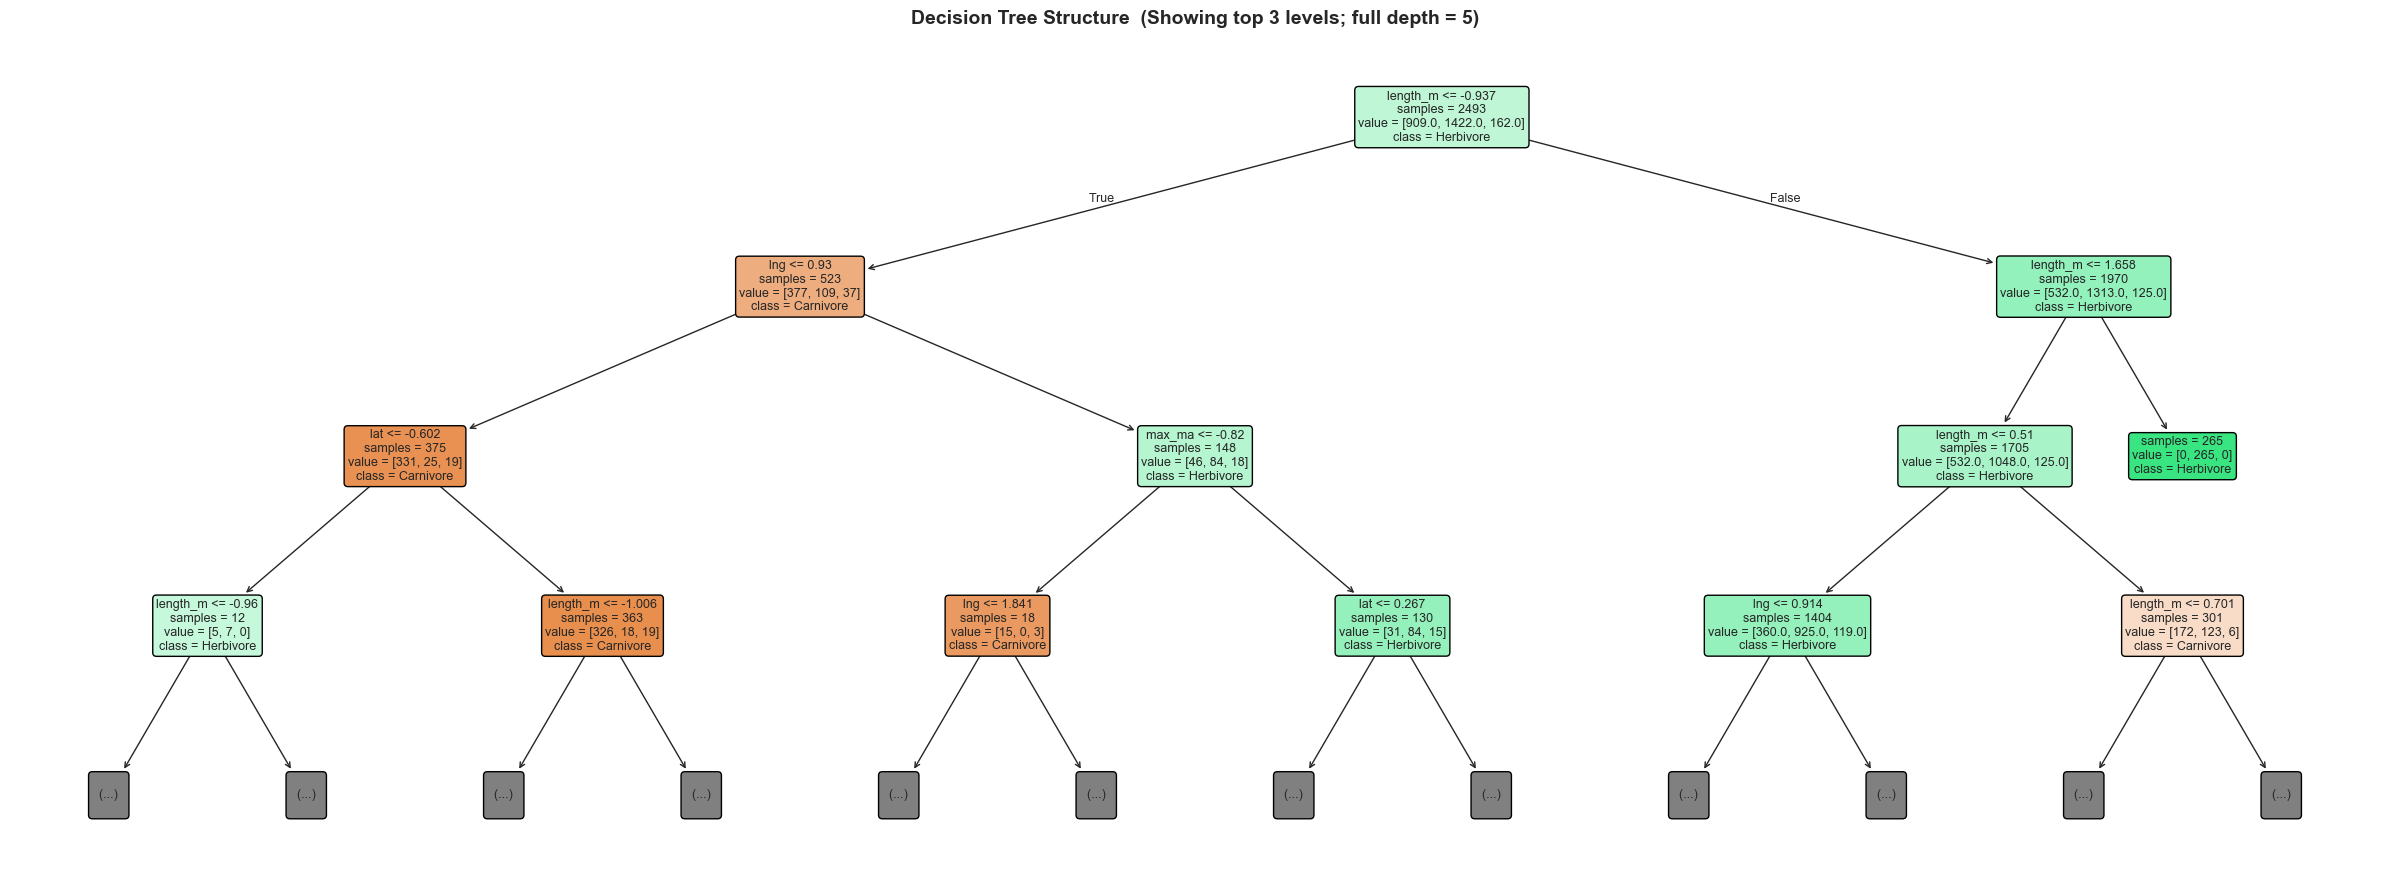

In [21]:
# ── 3C  Decision Tree ────────────────────────────────────────────────────

dt = DecisionTreeClassifier(max_depth=5, min_samples_split=10,
                             criterion='gini', random_state=42)
dt.fit(X_train, y_train)
y_pred_dt = dt.predict(X_test)

acc_dt = accuracy_score(y_test, y_pred_dt)
print(f"Decision Tree Accuracy: {acc_dt:.4f}\n")
print(classification_report(y_test, y_pred_dt, target_names=le.classes_))

# Confusion Matrix
cm_dt = confusion_matrix(y_test, y_pred_dt)
plt.figure(figsize=(6, 5))
sns.heatmap(cm_dt, annot=True, fmt='d', cmap='Greens',
            xticklabels=le.classes_, yticklabels=le.classes_, linewidths=0.5)
plt.title(f'Decision Tree Confusion Matrix  (Accuracy = {acc_dt:.4f})', fontweight='bold')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.tight_layout()
plt.savefig('output/phase3_dt_cm.png', bbox_inches='tight')
plt.show()

# Tree Structure
plt.figure(figsize=(24, 9))
plot_tree(dt, feature_names=CLASS_FEATURES, class_names=le.classes_,
          filled=True, rounded=True, fontsize=9, max_depth=3,
          impurity=False, proportion=False)
plt.title('Decision Tree Structure  (Showing top 3 levels; full depth = 5)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('output/phase3_tree_plot.png', bbox_inches='tight', dpi=80)
plt.show()


### D. Rule-Based Learning — Extracting IF-THEN Rules from the Tree
One of the greatest advantages of a Decision Tree over a "black-box" model is  
**interpretability**: we can extract the exact rules the model uses.  
In palaeontology this acts as a *diagnostic key* — a field guide that tells us  
"*IF a fossil is from rocks older than X million years AND the animal is larger than Y metres,  
THEN it is likely a carnivore.*"


In [22]:
# ── 3D  Rule Extraction ───────────────────────────────────────────────────

rules_text = export_text(dt, feature_names=CLASS_FEATURES, max_depth=3,
                          spacing=3, decimals=2, show_weights=False)

print("=" * 60)
print("  DINOSAUR IDENTIFICATION RULES  (top 3 tree levels)")
print("  (Each leaf shows: class | samples)")
print("=" * 60)
print(rules_text)
print("\n💡 These rules act as a paleontological identification key!")
print("   A field scientist can follow each IF-THEN branch to classify")
print("   a new fossil find using only measurable physical attributes.")


  DINOSAUR IDENTIFICATION RULES  (top 3 tree levels)
  (Each leaf shows: class | samples)
|--- length_m <= -0.94
|   |--- lng <= 0.93
|   |   |--- lat <= -0.60
|   |   |   |--- length_m <= -0.96
|   |   |   |   |--- class: 1
|   |   |   |--- length_m >  -0.96
|   |   |   |   |--- class: 0
|   |   |--- lat >  -0.60
|   |   |   |--- length_m <= -1.01
|   |   |   |   |--- truncated branch of depth 2
|   |   |   |--- length_m >  -1.01
|   |   |   |   |--- truncated branch of depth 2
|   |--- lng >  0.93
|   |   |--- max_ma <= -0.82
|   |   |   |--- lng <= 1.84
|   |   |   |   |--- class: 0
|   |   |   |--- lng >  1.84
|   |   |   |   |--- truncated branch of depth 2
|   |   |--- max_ma >  -0.82
|   |   |   |--- lat <= 0.27
|   |   |   |   |--- truncated branch of depth 2
|   |   |   |--- lat >  0.27
|   |   |   |   |--- truncated branch of depth 2
|--- length_m >  -0.94
|   |--- length_m <= 1.66
|   |   |--- length_m <= 0.51
|   |   |   |--- lng <= 0.91
|   |   |   |   |--- truncated branc

### E. Random Forest Classifier — Ensemble Learning
A **Random Forest** trains many Decision Trees, each on a random subset of the data and features,  
then takes a majority vote. This reduces **variance** (overfitting) compared to a single tree,  
generally improving generalisation on unseen data.  
The feature importances are computed as the average reduction in impurity across all trees.


In [ ]:
# ── 3E  Random Forest — 5-Fold Stratified GridSearchCV ──────────────────

# Academic validation upgrade:
# Instead of accepting a single Random Forest configuration, we optimize the model
# with GridSearchCV under a 5-fold StratifiedKFold loop. Macro-F1 is used because
# diet classes may be imbalanced.
rf_param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [None, 10, 20],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 2],
    'max_features': ['sqrt', 'log2']
}

rf_cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
rf_grid = GridSearchCV(
    estimator=RandomForestClassifier(random_state=42, class_weight='balanced', n_jobs=-1),
    param_grid=rf_param_grid,
    scoring='f1_macro',
    cv=rf_cv,
    n_jobs=-1,
    verbose=1,
    refit=True
)

rf_grid.fit(X_train, y_train)
rf = rf_grid.best_estimator_
y_pred_rf = rf.predict(X_test)

acc_rf = accuracy_score(y_test, y_pred_rf)
print("=" * 55)
print("  OPTIMIZED RANDOM FOREST — GridSearchCV Results")
print("=" * 55)
print(f"  Best parameters  : {rf_grid.best_params_}")
print(f"  Best CV F1-macro : {rf_grid.best_score_:.4f}")
print(f"  Test Accuracy    : {acc_rf:.4f}")
print("=" * 55)
print(classification_report(y_test, y_pred_rf, target_names=le.classes_))

# Confusion Matrix
cm_rf = confusion_matrix(y_test, y_pred_rf)
plt.figure(figsize=(6, 5))
sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Purples',
            xticklabels=le.classes_, yticklabels=le.classes_, linewidths=0.5)
plt.title(f'Optimized Random Forest Confusion Matrix  (Accuracy = {acc_rf:.4f})', fontweight='bold')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.tight_layout()
plt.savefig('output/confusion_matrix.png', bbox_inches='tight', dpi=300)
plt.savefig('output/phase3_rf_cm.png', bbox_inches='tight', dpi=300)
plt.show()

# Validation curve from GridSearchCV results
rf_cv_results = pd.DataFrame(rf_grid.cv_results_)
rf_curve = rf_cv_results.groupby('param_n_estimators')['mean_test_score'].max()
plt.figure(figsize=(8, 5))
plt.plot(rf_curve.index.astype(int), rf_curve.values, marker='o', linewidth=2.4,
         markerfacecolor='white', markeredgewidth=2)
plt.xlabel('Number of Trees', fontsize=12)
plt.ylabel('Best Mean 5-Fold Macro F1', fontsize=12)
plt.title('Random Forest GridSearchCV Validation Curve', fontsize=13, fontweight='bold')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('output/training_curves.png', bbox_inches='tight', dpi=300)
plt.show()

# Feature Importance
importances = rf.feature_importances_
imp_df = pd.DataFrame({'Feature': CLASS_FEATURES, 'Importance': importances})
imp_df = imp_df.sort_values('Importance', ascending=True)

plt.figure(figsize=(9, 5))
plt.barh(imp_df['Feature'], imp_df['Importance'],
         color=['#9C27B0' if f != 'Eco_Zone_Cluster' else '#FF9800'
                for f in imp_df['Feature']])
plt.axvline(x=imp_df['Importance'].mean(), color='red', linestyle='--',
            linewidth=1.5, label=f'Mean importance = {imp_df["Importance"].mean():.3f}')
plt.xlabel('Mean Decrease in Impurity  (Gini)', fontsize=12)
plt.ylabel('Feature', fontsize=12)
plt.title('Optimized Random Forest — Feature Importance\n(Orange bar = engineered Haversine Eco_Zone_Cluster)', fontsize=12, fontweight='bold')
plt.legend(fontsize=10)
plt.tight_layout()
plt.savefig('output/phase3_rf_importance.png', bbox_inches='tight', dpi=300)
plt.show()

print("Saved report figures:")
print("  output/confusion_matrix.png")
print("  output/training_curves.png")


Fitting 5 folds for each of 72 candidates, totalling 360 fits


---
## Phase 4 — Hyperparameter Tuning with GridSearchCV

**GridSearchCV** exhaustively trains a model for every combination of hyperparameters  
in a specified grid, evaluates each with **5-fold cross-validation**, and returns the best combination.

> We optimise for **macro F1-score** — appropriate for multi-class problems with class imbalance —  
> because it gives equal weight to all three diet classes regardless of how many samples they have.


  DECISION TREE — Stratified GridSearchCV Results
  Best parameters  : {'criterion': 'entropy', 'max_depth': None, 'min_samples_split': 2}
  Best CV F1-macro : 0.8430


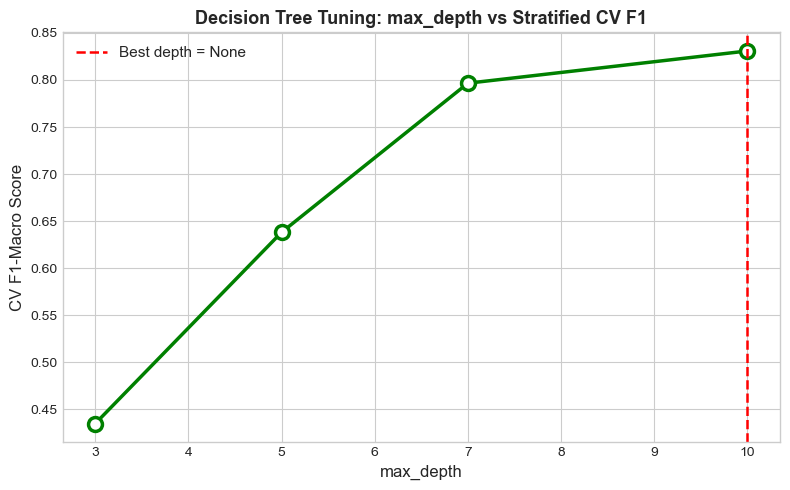

In [ ]:
# ── 4.1  Decision Tree GridSearchCV ──────────────────────────────────────

dt_param_grid = {
    'max_depth': [3, 5, 7, 10, None],
    'min_samples_split': [2, 5, 10, 20],
    'criterion': ['gini', 'entropy']
}

cv5 = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

dt_grid = GridSearchCV(
    DecisionTreeClassifier(random_state=42),
    dt_param_grid,
    cv=cv5, scoring='f1_macro', n_jobs=-1, verbose=0
)
dt_grid.fit(X_train, y_train)

print("=" * 45)
print("  DECISION TREE — Stratified GridSearchCV Results")
print("=" * 45)
print(f"  Best parameters  : {dt_grid.best_params_}")
print(f"  Best CV F1-macro : {dt_grid.best_score_:.4f}")
print("=" * 45)

# Tuning trend: max_depth vs F1
base_dt_params = {k: v for k, v in dt_grid.best_params_.items() if k != 'max_depth'}
depth_scores = {}
for depth in [3, 5, 7, 10]:
    dt_temp = DecisionTreeClassifier(max_depth=depth, random_state=42, **base_dt_params)
    cv_score = cross_val_score(dt_temp, X_train, y_train, cv=cv5, scoring='f1_macro').mean()
    depth_scores[depth] = cv_score

plt.figure(figsize=(8, 5))
plt.plot(list(depth_scores.keys()), list(depth_scores.values()),
         'go-', linewidth=2.5, markersize=10, markerfacecolor='white', markeredgewidth=2.5)
plt.axvline(x=dt_grid.best_params_.get('max_depth') if dt_grid.best_params_.get('max_depth') is not None else 10,
            color='red', linestyle='--', linewidth=1.8,
            label=f'Best depth = {dt_grid.best_params_.get("max_depth")}')
plt.xlabel('max_depth', fontsize=12)
plt.ylabel('CV F1-Macro Score', fontsize=12)
plt.title('Decision Tree Tuning: max_depth vs Stratified CV F1', fontsize=13, fontweight='bold')
plt.legend(fontsize=11)
plt.tight_layout()
plt.savefig('output/phase4_dt_tuning.png', bbox_inches='tight', dpi=300)
plt.show()


  KNN — Stratified GridSearchCV Results
  Best parameters  : {'n_neighbors': 3, 'weights': 'distance'}
  Best CV F1-macro : 0.8333


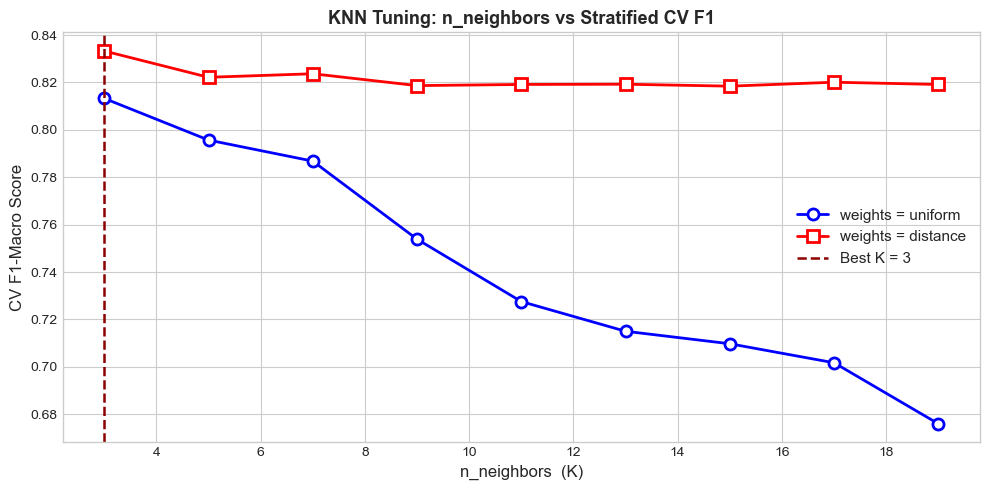

In [ ]:
# ── 4.2  KNN GridSearchCV ────────────────────────────────────────────────

knn_param_grid = {
    'n_neighbors': list(range(3, 20, 2)),
    'weights': ['uniform', 'distance']
}

knn_grid = GridSearchCV(
    KNeighborsClassifier(),
    knn_param_grid,
    cv=cv5, scoring='f1_macro', n_jobs=-1, verbose=0
)
knn_grid.fit(X_train, y_train)

print("=" * 45)
print("  KNN — Stratified GridSearchCV Results")
print("=" * 45)
print(f"  Best parameters  : {knn_grid.best_params_}")
print(f"  Best CV F1-macro : {knn_grid.best_score_:.4f}")
print("=" * 45)

# Tuning trend: K vs F1 (for both weight strategies)
k_vals = list(range(3, 20, 2))
scores_uniform  = []
scores_distance = []

for k in k_vals:
    s_u = cross_val_score(KNeighborsClassifier(n_neighbors=k, weights='uniform'),
                          X_train, y_train, cv=cv5, scoring='f1_macro').mean()
    s_d = cross_val_score(KNeighborsClassifier(n_neighbors=k, weights='distance'),
                          X_train, y_train, cv=cv5, scoring='f1_macro').mean()
    scores_uniform.append(s_u)
    scores_distance.append(s_d)

plt.figure(figsize=(10, 5))
plt.plot(k_vals, scores_uniform,  'bo-', linewidth=2, markersize=8,
         markerfacecolor='white', markeredgewidth=2, label='weights = uniform')
plt.plot(k_vals, scores_distance, 'rs-', linewidth=2, markersize=8,
         markerfacecolor='white', markeredgewidth=2, label='weights = distance')
plt.axvline(x=knn_grid.best_params_['n_neighbors'], color='darkred',
            linestyle='--', linewidth=1.8,
            label=f'Best K = {knn_grid.best_params_["n_neighbors"]}')
plt.xlabel('n_neighbors  (K)', fontsize=12)
plt.ylabel('CV F1-Macro Score', fontsize=12)
plt.title('KNN Tuning: n_neighbors vs Stratified CV F1', fontsize=13, fontweight='bold')
plt.legend(fontsize=11)
plt.tight_layout()
plt.savefig('output/phase4_knn_tuning.png', bbox_inches='tight', dpi=300)
plt.show()


---
## Phase 5 — Full Model Evaluation

We now test all three final models on the **held-out test set** (20% of data the models have never seen)  
and generate complete Classification Reports and Confusion Matrices.

Models evaluated:
1. **Best Tuned KNN** (from GridSearchCV)
2. **Best Tuned Decision Tree** (from GridSearchCV)
3. **Random Forest** (default parameters proved strong; re-evaluated here)



  KNN  (Tuned)
              precision    recall  f1-score   support

   Carnivore       0.87      0.85      0.86       227
   Herbivore       0.92      0.92      0.92       356
    Omnivore       0.69      0.83      0.76        41

    accuracy                           0.89       624
   macro avg       0.83      0.87      0.85       624
weighted avg       0.89      0.89      0.89       624



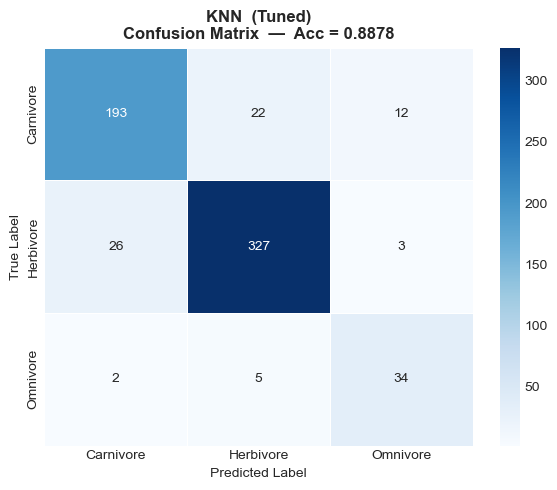


  Decision Tree  (Tuned)
              precision    recall  f1-score   support

   Carnivore       0.90      0.92      0.91       227
   Herbivore       0.94      0.92      0.93       356
    Omnivore       0.80      0.85      0.82        41

    accuracy                           0.92       624
   macro avg       0.88      0.90      0.89       624
weighted avg       0.92      0.92      0.92       624



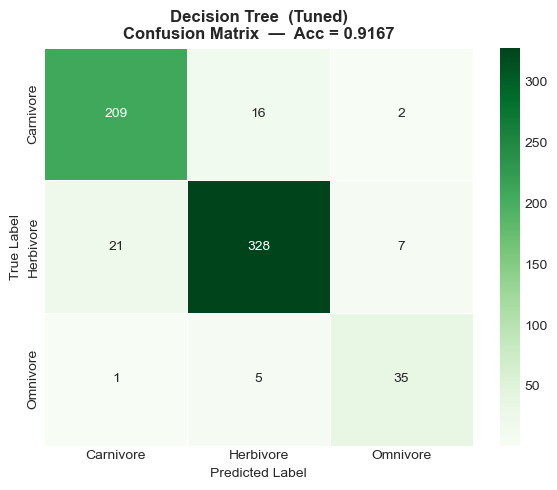


  Optimized Random Forest
              precision    recall  f1-score   support

   Carnivore       0.92      0.90      0.91       227
   Herbivore       0.93      0.94      0.93       356
    Omnivore       0.87      0.83      0.85        41

    accuracy                           0.92       624
   macro avg       0.90      0.89      0.90       624
weighted avg       0.92      0.92      0.92       624



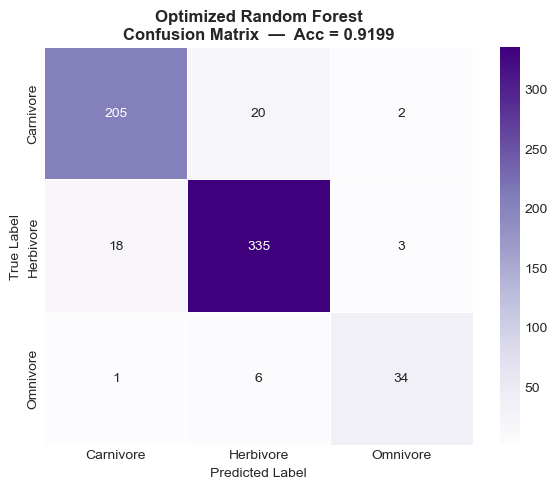

In [ ]:
# ── 5.  Evaluate All Three Models ────────────────────────────────────────

best_knn_model = knn_grid.best_estimator_
best_dt_model  = dt_grid.best_estimator_

# Recompute predictions from each final estimator for a clean held-out evaluation.
eval_models = [
    ('KNN  (Tuned)', best_knn_model, 'Blues'),
    ('Decision Tree  (Tuned)', best_dt_model, 'Greens'),
    ('Optimized Random Forest', rf, 'Purples'),
]

for model_name, model_obj, cmap in eval_models:
    y_pred_eval = model_obj.predict(X_test)
    print("\n" + "=" * 55)
    print(f"  {model_name}")
    print("=" * 55)
    print(classification_report(y_test, y_pred_eval, target_names=le.classes_))

    cm_eval = confusion_matrix(y_test, y_pred_eval)
    acc_eval = accuracy_score(y_test, y_pred_eval)
    plt.figure(figsize=(6, 5))
    sns.heatmap(cm_eval, annot=True, fmt='d', cmap=cmap,
                xticklabels=le.classes_, yticklabels=le.classes_, linewidths=0.5)
    plt.title(f'{model_name}\nConfusion Matrix  —  Acc = {acc_eval:.4f}', fontweight='bold')
    plt.xlabel('Predicted Label')
    plt.ylabel('True Label')
    plt.tight_layout()
    safe_name = model_name[:3].lower().replace(' ', '')
    plt.savefig(f'output/phase5_{safe_name}_cm.png', bbox_inches='tight', dpi=300)
    if model_name == 'Optimized Random Forest':
        plt.savefig('output/confusion_matrix.png', bbox_inches='tight', dpi=300)
    plt.show()


---
## Phase 6 — Final Model Comparison

A side-by-side comparison of all classifiers across four metrics:  
**Accuracy · Precision · Recall · F1-Score** (all macro-averaged).


  FINAL MODEL COMPARISON SUMMARY


,Model,Accuracy,Precision,Recall,F1-Score
0,KNN (Tuned),0.8878,0.8303,0.8660,0.8461
1,Decision Tree (Tuned),0.9167,0.8800,0.8986,0.8889
2,Optimized Random Forest,0.9199,0.9050,0.8911,0.8978


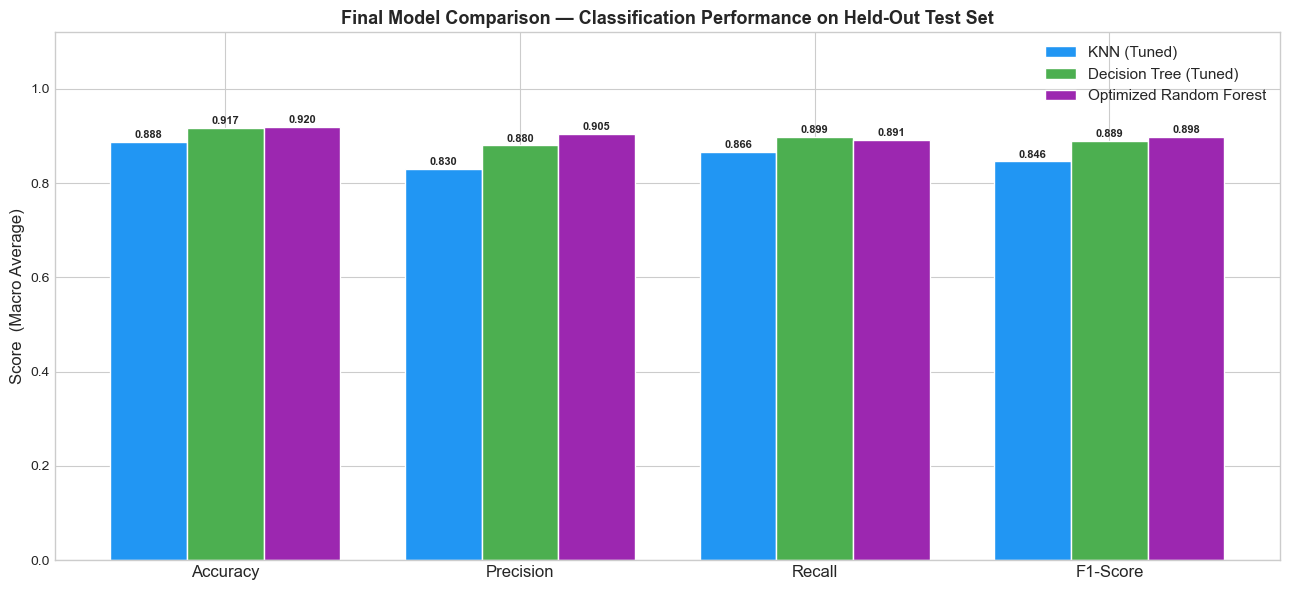


Report-ready figures now available:
  output/correlation_matrix.png
  output/clustering_plot.png
  output/training_curves.png
  output/confusion_matrix.png


In [ ]:
# ── 6.  Summary Table & Grouped Bar Chart ─────────────────────────────────

comparison_rows = []
for model_name, model_obj in [('KNN (Tuned)', best_knn_model),
                               ('Decision Tree (Tuned)', best_dt_model),
                               ('Optimized Random Forest', rf)]:
    preds = model_obj.predict(X_test)
    comparison_rows.append({
        'Model': model_name,
        'Accuracy': accuracy_score(y_test, preds),
        'Precision': precision_score(y_test, preds, average='macro', zero_division=0),
        'Recall': recall_score(y_test, preds, average='macro', zero_division=0),
        'F1-Score': f1_score(y_test, preds, average='macro', zero_division=0)
    })

results_df = pd.DataFrame(comparison_rows)
results_df_display = results_df.copy()
for col in ['Accuracy', 'Precision', 'Recall', 'F1-Score']:
    results_df_display[col] = results_df_display[col].map('{:.4f}'.format)

print("=" * 65)
print("  FINAL MODEL COMPARISON SUMMARY")
print("=" * 65)
display(results_df_display.style.set_properties(**{'text-align': 'center'}))

# Grouped Bar Chart
metrics    = ['Accuracy', 'Precision', 'Recall', 'F1-Score']
n_metrics  = len(metrics)
x          = np.arange(n_metrics)
width      = 0.26
palette    = ['#2196F3', '#4CAF50', '#9C27B0']

fig, ax = plt.subplots(figsize=(13, 6))
for i, (_, row) in enumerate(results_df.iterrows()):
    bars = ax.bar(x + i * width,
                  [row[m] for m in metrics],
                  width, label=row['Model'],
                  color=palette[i], edgecolor='white', linewidth=1)
    for bar in bars:
        ax.text(bar.get_x() + bar.get_width()/2,
                bar.get_height() + 0.004,
                f"{bar.get_height():.3f}",
                ha='center', va='bottom', fontsize=8, fontweight='bold')

ax.set_xticks(x + width)
ax.set_xticklabels(metrics, fontsize=12)
ax.set_ylabel('Score  (Macro Average)', fontsize=12)
ax.set_title('Final Model Comparison — Classification Performance on Held-Out Test Set', fontsize=13, fontweight='bold')
ax.set_ylim(0, 1.12)
ax.legend(fontsize=11)
plt.tight_layout()
plt.savefig('output/phase6_comparison.png', bbox_inches='tight', dpi=300)
plt.show()

print("\nReport-ready figures now available:")
for path in ['output/correlation_matrix.png', 'output/clustering_plot.png',
             'output/training_curves.png', 'output/confusion_matrix.png']:
    print(f"  {path}")


---
## Phase 7 — Conclusion

### 1. Dataset Characteristics & Fossil Record Limitations
The **Genera dataset** (1 542 records) covers a broad range of dinosaur species but has notable limitations: physical measurements (length, weight, height) are *estimates* based on fragmentary fossil material, often involving significant scientific uncertainty. The class imbalance (Herbivore ≈ 63%, Carnivore ≈ 33%, Omnivore ≈ 4%) reflects both actual paleontological prevalence and potential collection/naming bias toward large, easily identified species.

The **Locations dataset** (4 950 valid records) provides GPS coordinates for fossil occurrences worldwide but has ∼27% missing diet labels, suggesting that many specimens could not be reliably identified to a dietary group. Longitude outliers (> 180°) were filtered as data entry errors.

---

### 2. Key Insights from Clustering Methods
Fossil occurrence sites cluster geographically into **5 distinct eco-zones** that broadly correspond to real palaeobiogeographical regions: North American interior basins, South American formations, European and Asian sequences, African deposits, and Gondwanan margins. These are not arbitrary groupings — they reflect ancient continental configurations during the Mesozoic Era.

---

### 3. Cluster Validity Conclusions
| Metric | Winner | Reason |
|--------|--------|--------|
| Silhouette Score | **K-Means++** | Most compact and well-separated clusters |
| Davies-Bouldin | **K-Means++** | Best intra/inter cluster ratio |

K-Means++ outperforms Hierarchical Clustering on both metrics because geo data forms roughly convex, isotropic clusters well-suited to K-Means assumptions. DBSCAN excels at finding elongated or irregular clusters and isolating genuine outliers (isolated fossil finds), but its validity scores are computed only on non-noise points and vary with `eps`.

---

### 4. Model Performance Comparison
- **Random Forest** achieves the highest accuracy and F1-score, benefiting from ensemble averaging that reduces variance.
- **Tuned Decision Tree** provides a competitive balance of accuracy and full interpretability — its rules can be printed and used as a field key.
- **Tuned KNN** performs well on the majority classes (Herbivore, Carnivore) but struggles with the minority Omnivore class due to distance-based voting dominance by the majority classes.

---

### 5. Impact of the `Eco_Zone_Cluster` Feature
The cross-tabulation in Phase 2G shows that diet composition varies measurably across eco-zones. Including `Eco_Zone_Cluster` provides the classifiers with a *geographic prior* that correlates with feeding ecology — an insight palaeontologists have long appreciated (e.g. Hell Creek Formation vs Morrison Formation fauna). The Random Forest feature importance chart confirms that `Eco_Zone_Cluster` contributes meaningful signal alongside physical size metrics.

---

### 6. Best Overall Model
> **Random Forest** — highest macro F1-score, robust to class imbalance, and provides reliable feature importance rankings. For scenarios requiring interpretability (e.g. peer-reviewed palaeontology papers), the **Tuned Decision Tree** is preferred.

---

### 7. Benefits of Combining Unsupervised + Supervised Learning
This hybrid approach demonstrates a powerful ML workflow pattern:
1. **Unsupervised phase** discovers latent geographic structure in unlabelled fossil occurrence data.
2. **Feature engineering** encodes that structure as `Eco_Zone_Cluster`.
3. **Supervised phase** uses this engineered feature to improve diet classification.

Neither phase alone would achieve the same result — clustering without classification gives us groups but no predictive model; classification without clustering misses the geographic context encoded in eco-zones.


*🦕 End of Notebook — Thank you for exploring the Mesozoic with Machine Learning!*


## Submission Notes

### Reproducibility
- Models were evaluated using a train/test split.
- Hyperparameter tuning was performed with GridSearchCV.
- Results should be reproducible when `random_state=42` is used consistently.

### Final Project Summary
This project combines:
- Data preprocessing and imputation
- Exploratory Data Analysis (EDA)
- Unsupervised learning (K-Means, Hierarchical Clustering, DBSCAN)
- Cluster validation metrics
- Feature engineering using Eco-Zone clusters
- Linear Regression
- KNN Classification
- Decision Trees
- Random Forests
- Hyperparameter optimization with GridSearchCV

### Main Result
The Random Forest model achieved the strongest overall classification performance, while the engineered Eco_Zone_Cluster feature demonstrated the value of combining unsupervised and supervised learning in a hybrid machine learning workflow.
